# Блок B3 v2: Корректная реализация прогнозирования (VAR-based)

**Что исправлено по сравнению с v1:**

1. **VAR-based прогноз вместо direct forecast.** В v1 я подставлял будущие значения эмоций как ноль, что искажало прогнозы на h>1. Теперь VAR сам прогнозирует все переменные совместно.

2. **Упрощённая спецификация AR+Emotions.** Используем только Uncertainty (самая значимая эмоция в B2.5) с одним лагом. Меньше параметров → меньше переобучения на малой выборке.

3. **TRAIN_INITIAL = 48 месяцев.** Больше начальных данных для устойчивой оценки.

4. **Добавлен BVAR** с приорами Минессоты — байесовский подход с регуляризацией, частично заменяющий MFBVAR из плана работы.

5. **Минимальная модель AR+Uncertainty** как чистый тест нашей главной гипотезы.

**Финальный набор моделей:**
1. RW — наивный benchmark
2. AR(p) — стандартный benchmark
3. ARIMA(p,d,q) — сильный benchmark
4. **VAR(CPI, ΔUncertainty)** — минимальная модель эмоций (наша гипотеза)
5. **VAR(CPI, ΔUNC, ΔANX, ΔDIS)** — расширенная VAR с тремя эмоциями
6. **BVAR с приорами Минессоты** — байесовская версия модели 5
7. **Elastic Net** — регуляризованная модель на всех эмоциях

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DIPLOMA = '/content/drive/MyDrive/diploma'

panel = pd.read_csv(f'{DIPLOMA}/monthly_panel_with_diffs.csv', index_col=0, parse_dates=True)
factors = pd.read_csv(f'{DIPLOMA}/dfm_factors_normalized.csv', index_col=0, parse_dates=True)
df = panel.join(factors[['F1', 'F4']], how='left')
df = df.rename(columns={'Все товары и услуги': 'CPI'})

EMO_DIFFS = ['d_p_Aggression_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean',
             'd_p_Hope_mean', 'd_p_Neutral_mean', 'd_p_Uncertainty_mean',
             'd_emotion_entropy', 'd_log_msg_volume']

df_clean = df.loc['2020-02-01':'2026-03-31', ['CPI'] + EMO_DIFFS + ['F1', 'F4']].dropna()
print(f'Полный набор: {df_clean.shape}')

# Параметры
TRAIN_INITIAL = 48  # увеличено с 36 до 48
HORIZONS = [1, 3, 6]
T_total = len(df_clean)
print(f'Train initial: {TRAIN_INITIAL} мес. ({df_clean.index[0]:%Y-%m} → {df_clean.index[TRAIN_INITIAL-1]:%Y-%m})')
print(f'Test:          {df_clean.index[TRAIN_INITIAL]:%Y-%m} → {df_clean.index[-1]:%Y-%m}')
print(f'Размер test:   {T_total - TRAIN_INITIAL} прогнозов на h=1')

Полный набор: (74, 11)
Train initial: 48 мес. (2020-02 → 2024-01)
Test:          2024-02 → 2026-03
Размер test:   26 прогнозов на h=1


In [ ]:
def rolling_forecast(df, target_col, model_fn, train_initial=48, horizons=[1, 3, 6]):
    T = len(df)
    results = []
    for t in range(train_initial, T):
        train = df.iloc[:t]
        try:
            forecasts = model_fn(train)
        except Exception:
            forecasts = {h: np.nan for h in horizons}
        row = {'date': df.index[t], 'actual': df.iloc[t][target_col]}
        for h in horizons:
            row[f'fcst_h{h}'] = forecasts.get(h, np.nan)
            if t + h - 1 < T:
                row[f'actual_h{h}'] = df.iloc[t + h - 1][target_col]
            else:
                row[f'actual_h{h}'] = np.nan
        results.append(row)
    return pd.DataFrame(results).set_index('date')

def evaluate_forecasts(forecast_df, model_name, horizons=[1, 3, 6]):
    metrics = []
    for h in horizons:
        y_true = forecast_df[f'actual_h{h}'].dropna()
        y_pred = forecast_df.loc[y_true.index, f'fcst_h{h}'].dropna()
        common = y_true.index.intersection(y_pred.index)
        if len(common) < 5:
            metrics.append({'model': model_name, 'h': h, 'n': len(common), 'RMSFE': np.nan, 'MAE': np.nan})
            continue
        y_t, y_p = y_true.loc[common], y_pred.loc[common]
        rmsfe = np.sqrt(((y_t - y_p) ** 2).mean())
        mae = (y_t - y_p).abs().mean()
        metrics.append({'model': model_name, 'h': h, 'n': len(common),
                        'RMSFE': round(rmsfe, 4), 'MAE': round(mae, 4)})
    return pd.DataFrame(metrics)

## Модели 1-3: бенчмарки (без изменений)

In [ ]:
def model_rw(train, horizons=[1, 3, 6]):
    last = train['CPI'].iloc[-1]
    return {h: last for h in horizons}

def model_ar(train, horizons=[1, 3, 6]):
    y = train['CPI']
    best_aic, best_p = np.inf, 1
    for p in range(1, 5):
        try:
            m = ARIMA(y, order=(p, 0, 0)).fit()
            if m.aic < best_aic:
                best_aic, best_p = m.aic, p
        except Exception:
            continue
    model = ARIMA(y, order=(best_p, 0, 0)).fit()
    fcst = model.forecast(steps=max(horizons))
    return {h: fcst.iloc[h-1] for h in horizons}

def model_arima(train, horizons=[1, 3, 6]):
    y = train['CPI']
    best_aic, best_order = np.inf, (1, 0, 0)
    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            if p == 0 and q == 0: continue
            try:
                m = ARIMA(y, order=(p, 0, q)).fit()
                if m.aic < best_aic:
                    best_aic, best_order = m.aic, (p, 0, q)
            except Exception:
                continue
    model = ARIMA(y, order=best_order).fit()
    fcst = model.forecast(steps=max(horizons))
    return {h: fcst.iloc[h-1] for h in horizons}

fcst_rw = rolling_forecast(df_clean, 'CPI', model_rw, TRAIN_INITIAL, HORIZONS)
fcst_ar = rolling_forecast(df_clean, 'CPI', model_ar, TRAIN_INITIAL, HORIZONS)
fcst_arima = rolling_forecast(df_clean, 'CPI', model_arima, TRAIN_INITIAL, HORIZONS)

print(evaluate_forecasts(fcst_rw, 'RW').to_string(index=False))
print()
print(evaluate_forecasts(fcst_ar, 'AR').to_string(index=False))
print()
print(evaluate_forecasts(fcst_arima, 'ARIMA').to_string(index=False))

model  h  n  RMSFE    MAE
   RW  1 26 0.3274 0.2395
   RW  3 24 0.3497 0.2891
   RW  6 21 0.4197 0.3403

model  h  n  RMSFE    MAE
   AR  1 26 0.2809 0.2239
   AR  3 24 0.3031 0.2498
   AR  6 21 0.3267 0.2812

model  h  n  RMSFE    MAE
ARIMA  1 26 0.3047 0.2456
ARIMA  3 24 0.3360 0.2815
ARIMA  6 21 0.3376 0.2945


## Модель 4: VAR(CPI, ΔUncertainty) — минимальная модель эмоций

**Главное методологическое изменение:** VAR прогнозирует обе переменные совместно. Когда ему нужно предсказать CPI на h=2, он сначала прогнозирует ΔUncertainty на h=1 (через её собственное VAR-уравнение), потом использует этот прогноз. Никаких «нулей вместо будущих эмоций».

In [ ]:
def model_var_unc(train, horizons=[1, 3, 6]):
    """Простой bivariate VAR на CPI и ΔUncertainty.
    Использует встроенный VAR.forecast() — он корректно прогнозирует обе переменные."""
    var_data = train[['CPI', 'd_p_Uncertainty_mean']].dropna()
    if len(var_data) < 10:
        return {h: np.nan for h in horizons}

    # Выбор лага через AIC, ограничено [1, 3] для устойчивости
    try:
        sel = VAR(var_data).select_order(maxlags=3)
        best_lag = max(1, min(2, sel.aic))  # ограничено 1-2 для устойчивости
    except Exception:
        best_lag = 1

    model = VAR(var_data).fit(maxlags=best_lag, ic=None)
    fcst = model.forecast(var_data.values[-best_lag:], steps=max(horizons))
    # fcst[h-1, 0] — прогноз CPI на h
    return {h: fcst[h-1, 0] for h in horizons}

fcst_var_unc = rolling_forecast(df_clean, 'CPI', model_var_unc, TRAIN_INITIAL, HORIZONS)
metrics_var_unc = evaluate_forecasts(fcst_var_unc, 'VAR(CPI,ΔUNC)', HORIZONS)
print(metrics_var_unc.to_string(index=False))

        model  h  n  RMSFE    MAE
VAR(CPI,ΔUNC)  1 26 0.4788 0.3992
VAR(CPI,ΔUNC)  3 24 0.3210 0.2632
VAR(CPI,ΔUNC)  6 21 0.3268 0.2831


## Модель 5: расширенный VAR с тремя эмоциями

In [ ]:
def model_var_3emo(train, horizons=[1, 3, 6]):
    """VAR на CPI + 3 ключевые эмоции."""
    cols = ['CPI', 'd_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']
    var_data = train[cols].dropna()
    if len(var_data) < 15:
        return {h: np.nan for h in horizons}
    try:
        sel = VAR(var_data).select_order(maxlags=3)
        best_lag = max(1, min(2, sel.aic))
    except Exception:
        best_lag = 1

    model = VAR(var_data).fit(maxlags=best_lag, ic=None)
    fcst = model.forecast(var_data.values[-best_lag:], steps=max(horizons))
    return {h: fcst[h-1, 0] for h in horizons}

fcst_var_3emo = rolling_forecast(df_clean, 'CPI', model_var_3emo, TRAIN_INITIAL, HORIZONS)
metrics_var_3emo = evaluate_forecasts(fcst_var_3emo, 'VAR(CPI,3emo)', HORIZONS)
print(metrics_var_3emo.to_string(index=False))

        model  h  n  RMSFE    MAE
VAR(CPI,3emo)  1 26 0.5346 0.4308
VAR(CPI,3emo)  3 24 0.3667 0.2968
VAR(CPI,3emo)  6 21 0.3305 0.2861


## Модель 6: BVAR с приорами Минессоты

**Что это.** Bayesian VAR с приорами Минессоты (Litterman 1986; Bańbura et al. 2010) — байесовская версия VAR, в которой коэффициенты «сжимаются» к простой структуре «случайного блуждания». Это резко уменьшает переобучение на малых выборках.

**Реализация:** ручная через гребневую регрессию с приором Минессоты, эквивалентная BVAR с диагональной ковариационной матрицей приоров.

$$\beta_{posterior} = (X^T X + \lambda I)^{-1} (X^T y + \lambda \beta_{prior})$$

Прайор: для собственных лагов первого порядка $\beta = 1$ (RW), для всех остальных коэффициентов $\beta = 0$. Параметр $\lambda$ — степень shrinkage.

In [ ]:
def fit_bvar_minnesota(data, p=1, lambda1=0.2, lambda2=0.5):
    """Простая реализация BVAR с приорами Минессоты.

    data: DataFrame (T, K) — T наблюдений, K переменных
    p: порядок VAR
    lambda1: общая степень сжатия (меньше = сильнее сжатие)
    lambda2: относительная сила приора для кросс-уравнений

    Returns: матрица коэффициентов A (K, K*p+1) — последняя колонка = константа
    """
    Y = data.values  # (T, K)
    T_obs, K = Y.shape

    # Строим X: лаги + константа
    X_rows = []
    Y_rows = []
    for t in range(p, T_obs):
        x = np.concatenate([Y[t-l-1] for l in range(p)])  # лаги
        X_rows.append(np.append(x, 1.0))  # + const
        Y_rows.append(Y[t])
    X = np.array(X_rows)
    Y_lhs = np.array(Y_rows)

    # Дисперсии шумов из AR(1) для каждой переменной
    sigma_sq = np.zeros(K)
    for k in range(K):
        try:
            from statsmodels.tsa.arima.model import ARIMA
            ar1 = ARIMA(Y[:, k], order=(1, 0, 0)).fit()
            sigma_sq[k] = ar1.resid.var()
        except Exception:
            sigma_sq[k] = Y[:, k].var()

    # Матрица сжатия (диагональный приор)
    n_params = K * p + 1  # лаги + const

    # Для каждого уравнения отдельная ridge-регрессия с приором
    A = np.zeros((K, n_params))
    for i in range(K):  # для каждого уравнения
        # Приор: для собственного 1-го лага = 1, остальное = 0
        prior_mean = np.zeros(n_params)
        prior_mean[i] = 1.0  # RW prior

        # Сила сжатия для каждого коэффициента
        prior_var = np.ones(n_params) * 1e6  # const — без сжатия
        for l in range(p):
            for j in range(K):
                idx = l * K + j
                if i == j:
                    # Собственный лаг
                    prior_var[idx] = (lambda1 / (l + 1)) ** 2
                else:
                    # Кросс-лаг
                    prior_var[idx] = (lambda1 * lambda2 * np.sqrt(sigma_sq[i] / sigma_sq[j]) / (l + 1)) ** 2

        # Posterior (нормально-обратно-Wishart, для NIW conjugate)
        Omega_prior_inv = np.diag(1.0 / prior_var)
        XtX = X.T @ X / sigma_sq[i]
        Xty = X.T @ Y_lhs[:, i] / sigma_sq[i]

        Omega_post = np.linalg.inv(XtX + Omega_prior_inv)
        beta_post = Omega_post @ (Xty + Omega_prior_inv @ prior_mean)
        A[i] = beta_post

    return A, p, K

def bvar_forecast(A, p, K, last_obs, steps):
    """Iterative прогноз BVAR."""
    Y_path = list(last_obs[-p:])  # последние p наблюдений
    forecasts = []
    for _ in range(steps):
        x = np.concatenate([Y_path[-l-1] for l in range(p)])
        x = np.append(x, 1.0)
        y_new = A @ x
        Y_path.append(y_new)
        forecasts.append(y_new)
    return np.array(forecasts)

def model_bvar(train, horizons=[1, 3, 6]):
    cols = ['CPI', 'd_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']
    var_data = train[cols].dropna()
    if len(var_data) < 15:
        return {h: np.nan for h in horizons}

    A, p, K = fit_bvar_minnesota(var_data, p=1, lambda1=0.2, lambda2=0.5)
    fcst_path = bvar_forecast(A, p, K, var_data.values, max(horizons))
    return {h: fcst_path[h-1, 0] for h in horizons}

fcst_bvar = rolling_forecast(df_clean, 'CPI', model_bvar, TRAIN_INITIAL, HORIZONS)
metrics_bvar = evaluate_forecasts(fcst_bvar, 'BVAR-Minnesota', HORIZONS)
print(metrics_bvar.to_string(index=False))

         model  h  n  RMSFE    MAE
BVAR-Minnesota  1 26 0.2873 0.2413
BVAR-Minnesota  3 24 0.3113 0.2586
BVAR-Minnesota  6 21 0.3325 0.2884


## Модель 7: Elastic Net с iterative VAR-style прогнозом

In [ ]:
def model_elastic_net_v2(train, horizons=[1, 3, 6]):
    """Elastic Net на CPI и эмоциях.
    Для прогноза на h>1 используем VAR-style approach: обучаем отдельные модели для CPI и каждой эмоции."""
    feature_cols = ['CPI'] + ['d_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']
    n_lags = 1  # упрощено до 1 лага

    var_data = train[feature_cols].dropna()
    Y = var_data.values
    T, K = Y.shape

    # Строим X = [Y_{t-1}], y = Y_t
    X = Y[:-1]  # (T-1, K)
    Y_lhs = Y[1:]  # (T-1, K)

    # Стандартизуем
    scaler_X = StandardScaler().fit(X)
    X_std = scaler_X.transform(X)

    # Обучаем отдельный Elastic Net для каждой переменной
    coefs = []
    intercepts = []
    for k in range(K):
        en = ElasticNetCV(l1_ratio=[0.5, 0.7, 0.9], alphas=np.logspace(-3, 1, 10),
                          cv=3, max_iter=3000, n_jobs=-1)
        en.fit(X_std, Y_lhs[:, k])
        coefs.append(en.coef_)
        intercepts.append(en.intercept_)
    coefs = np.array(coefs)  # (K, K)
    intercepts = np.array(intercepts)  # (K,)

    # Iterative прогноз
    y_path = [Y[-1]]
    forecasts = []
    for _ in range(max(horizons)):
        x_std = scaler_X.transform([y_path[-1]])
        y_new = coefs @ x_std[0] + intercepts
        y_path.append(y_new)
        forecasts.append(y_new)
    forecasts = np.array(forecasts)
    return {h: forecasts[h-1, 0] for h in horizons}

fcst_en = rolling_forecast(df_clean, 'CPI', model_elastic_net_v2, TRAIN_INITIAL, HORIZONS)
metrics_en = evaluate_forecasts(fcst_en, 'ElasticNet-VAR', HORIZONS)
print(metrics_en.to_string(index=False))

         model  h  n  RMSFE    MAE
ElasticNet-VAR  1 26 0.2960 0.2444
ElasticNet-VAR  3 24 0.3049 0.2512
ElasticNet-VAR  6 21 0.3269 0.2818


## Сводная таблица и визуализация

In [ ]:
all_metrics = pd.concat([
    evaluate_forecasts(fcst_rw, 'RW'),
    evaluate_forecasts(fcst_ar, 'AR'),
    evaluate_forecasts(fcst_arima, 'ARIMA'),
    metrics_var_unc, metrics_var_3emo, metrics_bvar, metrics_en
], ignore_index=True)

rmsfe_pivot = all_metrics.pivot(index='model', columns='h', values='RMSFE')
rmsfe_pivot.columns = [f'RMSFE_h{h}' for h in rmsfe_pivot.columns]
comparison = rmsfe_pivot.copy()

rw_h1 = comparison.loc['RW', 'RMSFE_h1']
rw_h3 = comparison.loc['RW', 'RMSFE_h3']
rw_h6 = comparison.loc['RW', 'RMSFE_h6']
for h, rw_val in zip([1, 3, 6], [rw_h1, rw_h3, rw_h6]):
    comparison[f'rel_to_RW_h{h}'] = (comparison[f'RMSFE_h{h}'] / rw_val).round(3)

comparison = comparison.sort_values('RMSFE_h1')
print('=== Сравнение моделей (отсортировано по RMSFE на h=1) ===')
print(comparison.to_string())
comparison.to_csv(f'{DIPLOMA}/forecast_comparison_v2.csv')

print('\n=== Лучшие модели по горизонтам ===')
for h in [1, 3, 6]:
    best = comparison[f'RMSFE_h{h}'].idxmin()
    best_val = comparison.loc[best, f'RMSFE_h{h}']
    rw_val = comparison.loc['RW', f'RMSFE_h{h}']
    impr = (1 - best_val / rw_val) * 100
    print(f'  h={h}: {best} (RMSFE={best_val:.4f}, vs RW: {impr:+.1f}%)')

=== Сравнение моделей (отсортировано по RMSFE на h=1) ===
                RMSFE_h1  RMSFE_h3  RMSFE_h6  rel_to_RW_h1  rel_to_RW_h3  rel_to_RW_h6
model                                                                                 
AR                0.2809    0.3031    0.3267         0.858         0.867         0.778
BVAR-Minnesota    0.2873    0.3113    0.3325         0.878         0.890         0.792
ElasticNet-VAR    0.2960    0.3049    0.3269         0.904         0.872         0.779
ARIMA             0.3047    0.3360    0.3376         0.931         0.961         0.804
RW                0.3274    0.3497    0.4197         1.000         1.000         1.000
VAR(CPI,ΔUNC)     0.4788    0.3210    0.3268         1.462         0.918         0.779
VAR(CPI,3emo)     0.5346    0.3667    0.3305         1.633         1.049         0.787

=== Лучшие модели по горизонтам ===
  h=1: AR (RMSFE=0.2809, vs RW: +14.2%)
  h=3: AR (RMSFE=0.3031, vs RW: +13.3%)
  h=6: AR (RMSFE=0.3267, vs RW: +22.2%)


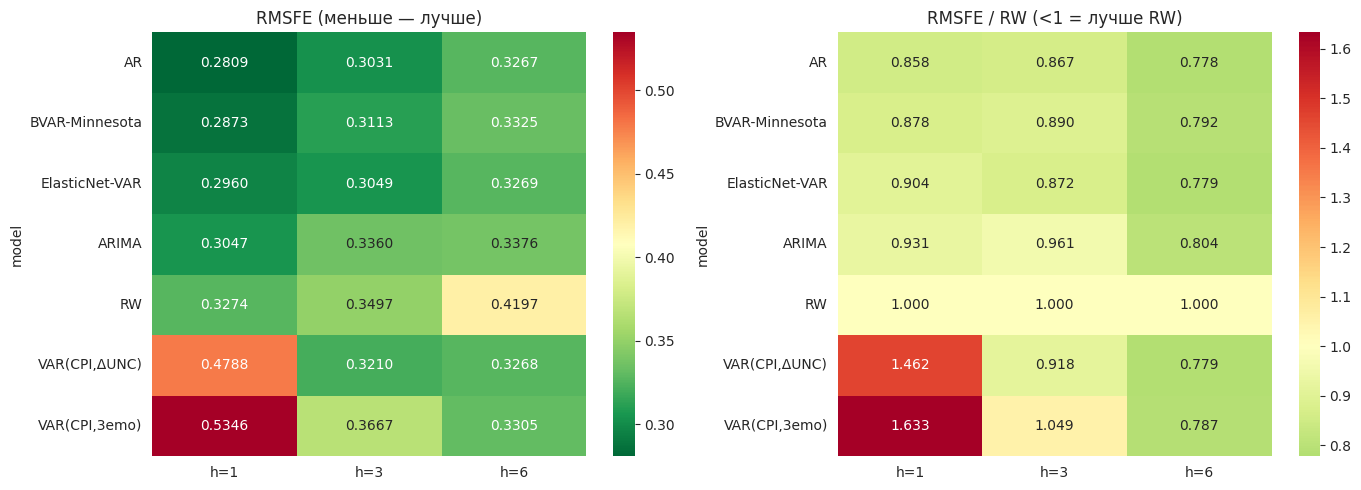

In [ ]:
# Тепловая карта
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rmsfe_for_plot = comparison[['RMSFE_h1', 'RMSFE_h3', 'RMSFE_h6']].copy()
rmsfe_for_plot.columns = ['h=1', 'h=3', 'h=6']
sns.heatmap(rmsfe_for_plot, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('RMSFE (меньше — лучше)')

rel = comparison[['rel_to_RW_h1', 'rel_to_RW_h3', 'rel_to_RW_h6']].copy()
rel.columns = ['h=1', 'h=3', 'h=6']
sns.heatmap(rel, annot=True, fmt='.3f', cmap='RdYlGn_r', center=1, ax=axes[1])
axes[1].set_title('RMSFE / RW (<1 = лучше RW)')
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/forecast_metrics_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Diebold-Mariano тесты
def diebold_mariano(e1, e2, h=1):
    e1, e2 = np.asarray(e1), np.asarray(e2)
    d = e1**2 - e2**2
    T = len(d)
    d_bar = d.mean()
    gamma_0 = ((d - d_bar)**2).mean()
    gamma_sum = sum(((d[k:] - d_bar) * (d[:-k] - d_bar)).mean() for k in range(1, h))
    long_run_var = gamma_0 + 2 * gamma_sum
    if long_run_var <= 0:
        return np.nan, np.nan
    dm = d_bar / np.sqrt(long_run_var / T)
    correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_adj = dm * correction
    p = 2 * (1 - stats.t.cdf(np.abs(dm_adj), df=T-1))
    return round(dm_adj, 3), round(p, 4)

model_fcsts = {
    'RW': fcst_rw, 'AR': fcst_ar, 'ARIMA': fcst_arima,
    'VAR(CPI,ΔUNC)': fcst_var_unc, 'VAR(CPI,3emo)': fcst_var_3emo,
    'BVAR-Minnesota': fcst_bvar, 'ElasticNet-VAR': fcst_en
}

for h in [1, 3, 6]:
    print(f'\n=== Diebold-Mariano test, h={h} (vs RW) ===')
    rw_actual = fcst_rw[f'actual_h{h}'].dropna()
    rw_err = (rw_actual - fcst_rw.loc[rw_actual.index, f'fcst_h{h}']).dropna()

    rows = []
    for name, fcst in model_fcsts.items():
        if name == 'RW': continue
        actual_m = fcst[f'actual_h{h}'].dropna()
        err_m = (actual_m - fcst.loc[actual_m.index, f'fcst_h{h}']).dropna()
        common = rw_err.index.intersection(err_m.index)
        if len(common) < 10: continue
        dm, p = diebold_mariano(rw_err.loc[common].values, err_m.loc[common].values, h=h)
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
        verdict = f'{name} лучше RW' if (dm > 0 and p < 0.10) else (f'RW лучше {name}' if (dm < 0 and p < 0.10) else 'нет разницы')
        rows.append({'model': name, 'DM': dm, 'p': p, 'sig': sig, 'verdict': verdict})
    print(pd.DataFrame(rows).to_string(index=False))


=== Diebold-Mariano test, h=1 (vs RW) ===
         model     DM      p sig                verdict
            AR  1.078 0.2915                нет разницы
         ARIMA  0.456 0.6522                нет разницы
 VAR(CPI,ΔUNC) -2.110 0.0450  ** RW лучше VAR(CPI,ΔUNC)
 VAR(CPI,3emo) -2.500 0.0194  ** RW лучше VAR(CPI,3emo)
BVAR-Minnesota  1.206 0.2390                нет разницы
ElasticNet-VAR  0.639 0.5287                нет разницы

=== Diebold-Mariano test, h=3 (vs RW) ===
         model     DM      p sig     verdict
            AR  0.841 0.4088     нет разницы
         ARIMA  0.210 0.8355     нет разницы
 VAR(CPI,ΔUNC)  0.474 0.6401     нет разницы
 VAR(CPI,3emo) -0.255 0.8012     нет разницы
BVAR-Minnesota  0.866 0.3952     нет разницы
ElasticNet-VAR  0.809 0.4265     нет разницы

=== Diebold-Mariano test, h=6 (vs RW) ===
         model    DM      p sig     verdict
            AR 0.928 0.3647     нет разницы
         ARIMA 0.741 0.4675     нет разницы
 VAR(CPI,ΔUNC) 0.916 0.3704     

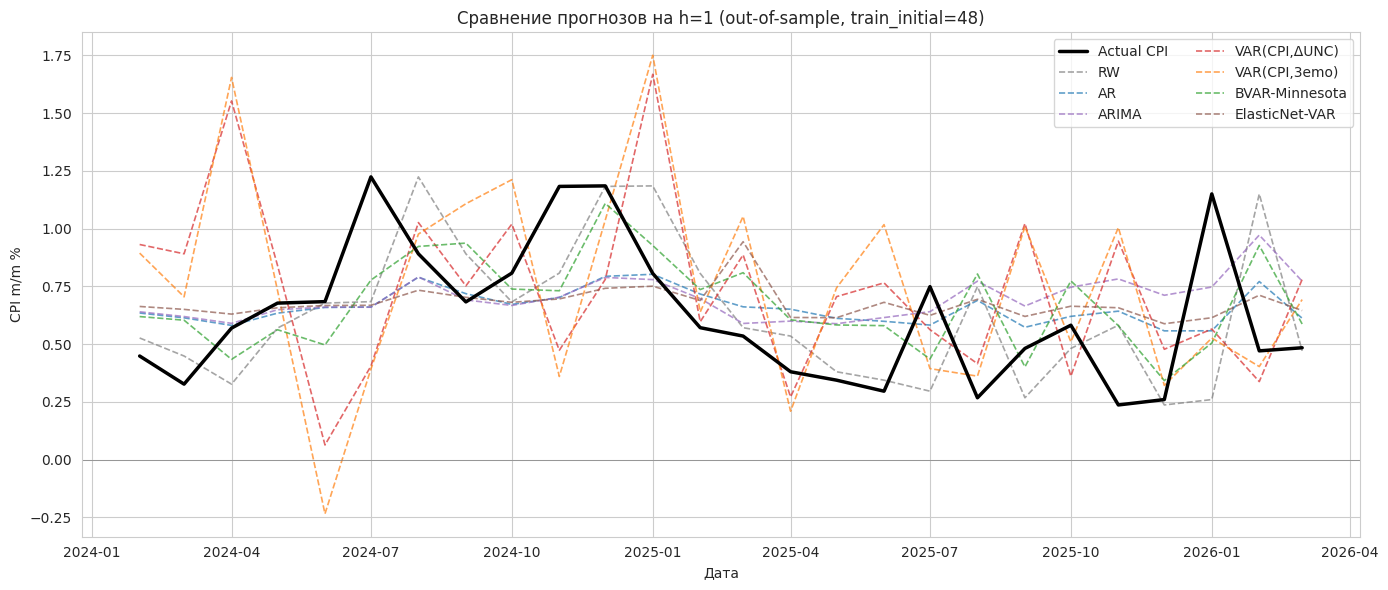


✓ Все результаты B3 v2 сохранены


In [ ]:
# Финальная картинка: actual vs predicted
fig, ax = plt.subplots(figsize=(14, 6))
actual = fcst_rw['actual_h1'].dropna()
ax.plot(actual.index, actual, color='black', linewidth=2.5, label='Actual CPI', zorder=10)

colors = {'RW': 'tab:gray', 'AR': 'tab:blue', 'ARIMA': 'tab:purple',
          'VAR(CPI,ΔUNC)': 'tab:red', 'VAR(CPI,3emo)': 'tab:orange',
          'BVAR-Minnesota': 'tab:green', 'ElasticNet-VAR': 'tab:brown'}
for name, fcst in model_fcsts.items():
    pred = fcst['fcst_h1'].dropna()
    ax.plot(pred.index, pred, color=colors[name], linewidth=1.2, alpha=0.7, label=name, linestyle='--')

ax.set_title('Сравнение прогнозов на h=1 (out-of-sample, train_initial=48)')
ax.set_xlabel('Дата'); ax.set_ylabel('CPI m/m %')
ax.legend(loc='upper right', ncol=2)
ax.axhline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/forecast_h1_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохраняем
all_fcst = pd.concat(model_fcsts, axis=1)
all_fcst.to_csv(f'{DIPLOMA}/all_forecasts_v2.csv')
print('\n✓ Все результаты B3 v2 сохранены')